# NICHOLAS MUCHIRI KINYUA

# Iris Flower Classification

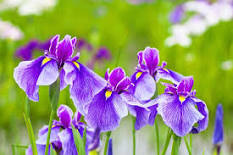

# Table of contents
[1. Business Understanding](#1.-Business-Understanding) </br>
[1.1 Business Description](#1.1-Business-Description) </br>
[1.2 Problem Statement](#1.2-Problem-Statement) </br>
[1.3 Main Objective](#1.3-Main-Objective) </br>
[1.4 Specific Objectives](#1.4-Specific-Objectives) </br>
[2. Importing Libraries And Warnings](#2.-Importing-Libraries-And-Warnings) </br>
[3. Data Understanding](#3.-Data-Understanding) </br>
[3.1. Loading The Data](#3.1-Loading-The-Data) </br>
[4. Data Cleaning](#4.-Data-Cleaning) </br>
[4.1. Visualizing The Data Before Cleaning](#4.1.-Visualizing-The-Data-Before-Cleaning) </br>
[4.2 Missing Values](#4.2-Missing-Values)</br>
[4.3 Duplicates](#4.3-Duplicates)</br>
[4.4 Outliers](#4.4-Outliers)</br>
[4.5 Visualizing After Data Cleaning](#4.5-Visualizing-After-Data-Cleaning) </br>
[5. EDA](#5.-EDA) </br>
[5.1 Univariate Analysis](#5.1-Univariate-Analysis) </br>
[5.2 Bivariate Analysis](#5.2-Bivariate-Analysis) </br>
[5.3 Multivariate Analysis](#5.3-Multivariate-Analysis) </br>
[6. Data Preprocessing](#6.-Data-Preprocessing) </br>
[6.1 Performing Train Test Split](#6.1-Performing-Train-Test-Split) </br>
[6.2 Scaling](#6.2-Scaling) </br>
[6.3 PCA](#6.3-PCA) </br>
[6.4 Correlation](#6.4-Correlation) </br>
[7. Data Modelling](#7.-Data-Modelling) </br>
[7.1 Logistic Regression](#7.1-Logistic-Regression) </br>
[7.2 SVM](#7.2-SVM) </br>
[7.3 Decision Trees](#7.3-Decision-Trees) </br>
[7.4 Random Forest](#7.4-Random-Forest) </br>
[7.5 KNN](#7.5-KNN) </br>
[7.6 Neural Networks](#7.6-Neural-Networks) </br>
[8. Evaluation](#8.-Evaluation) </br>
[8.1 Logistic Regression Model Test](#8.1-Logistic-Regression-Model-Test) </br>
[8.2 Random Forest Model Test](#8.2-Random-Forest-Model-Test) </br>
[8.3 KNN Model Test](#8.3-KNN-Model-Test) </br>
[9. Conclusions And Recommendations](#9.-Conclusions-And-Recommendations) </br>
[10. Challenges](#10.-Challenges)

# 1. Business Understanding

## 1.1 Business Description

Classify iris flowers into three species (setosa, versicolor, virginica) based on 

sepal length, </br> 
sepal width, </br>
petal length, </br>
petal width

# 1.2 Problem Statement

To develop a model that can accurately classify iris flowers into their respective species based on their physical characteristics.

# 1.3 Main Objective

To build a supervised learning model/models (now that I have the targets) that can learn from the provided dataset containing measurements of iris flowers.

# 1.4 Specific Objectives

### Classification: 
To build a model that can accurately classify Iris flowers into their three known species (Iris Setosa, Iris Versicolor, Iris Virginica) based on the provided measurements. This will involve learning the patterns i.e The model needs to identify the relationships between the flower measurements (sepal and petal dimensions) and the corresponding species.
### Evaluation:  
A key aspect of evaluation will be to compare the classification accuracy achieved using PCA. This will help me understand if dimensionality reduction through PCA benefits the model performance in this specific case.

# 2. Importing Libraries And Warnings

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
from sklearn.svm import SVC
from sklearn import datasets
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
from keras.utils import to_categorical
from keras import models, layers, optimizers
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 3. Data Understanding

## 3.1 Loading The Data

In [2]:
# loading the data uing pandas and assigning it a variable data
iris = datasets.load_iris()
iris = datasets.load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['target'] = iris.get('target')
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [4]:
data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
data.tail(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [6]:
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [8]:
data.shape

(150, 5)

In [9]:
for column in data.columns:
    unique_values = data[column].unique()
    print(f"unique values in {column}:", unique_values)

unique values in sepal length (cm): [5.1 4.9 4.7 4.6 5.  5.4 4.4 4.8 4.3 5.8 5.7 5.2 5.5 4.5 5.3 7.  6.4 6.9
 6.5 6.3 6.6 5.9 6.  6.1 5.6 6.7 6.2 6.8 7.1 7.6 7.3 7.2 7.7 7.4 7.9]
unique values in sepal width (cm): [3.5 3.  3.2 3.1 3.6 3.9 3.4 2.9 3.7 4.  4.4 3.8 3.3 4.1 4.2 2.3 2.8 2.4
 2.7 2.  2.2 2.5 2.6]
unique values in petal length (cm): [1.4 1.3 1.5 1.7 1.6 1.1 1.2 1.  1.9 4.7 4.5 4.9 4.  4.6 3.3 3.9 3.5 4.2
 3.6 4.4 4.1 4.8 4.3 5.  3.8 3.7 5.1 3.  6.  5.9 5.6 5.8 6.6 6.3 6.1 5.3
 5.5 6.7 6.9 5.7 6.4 5.4 5.2]
unique values in petal width (cm): [0.2 0.4 0.3 0.1 0.5 0.6 1.4 1.5 1.3 1.6 1.  1.1 1.8 1.2 1.7 2.5 1.9 2.1
 2.2 2.  2.4 2.3]
unique values in target: [0 1 2]


In [10]:
# Define a dictionary mapping numeric labels to class names
class_names = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}

In [11]:
data["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

The Iris dataset was used in R.A. Fisher's classic 1936 paper, The Use of Multiple Measurements in Taxonomic Problems, and can also be found on the UCI Machine Learning Repository.

It includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.

The dataset, Iris, has got 150 rows and 6 columns.
columns ae as follows: </br>
Id - The primary identifier </br>
sepal length (cm) - length of the sepal in centimeters </br>
sepal width (cm) - width of the sepal in centimeters </br>
petal length (cm) - length of the petal in centimeters </br>
petal width (cm) - width of the petal in centimeters </br>
target - The target amking this project a supervised machine learning project.

# 4. Data Cleaning

## 4.1. Visualizing The Data Before Cleaning

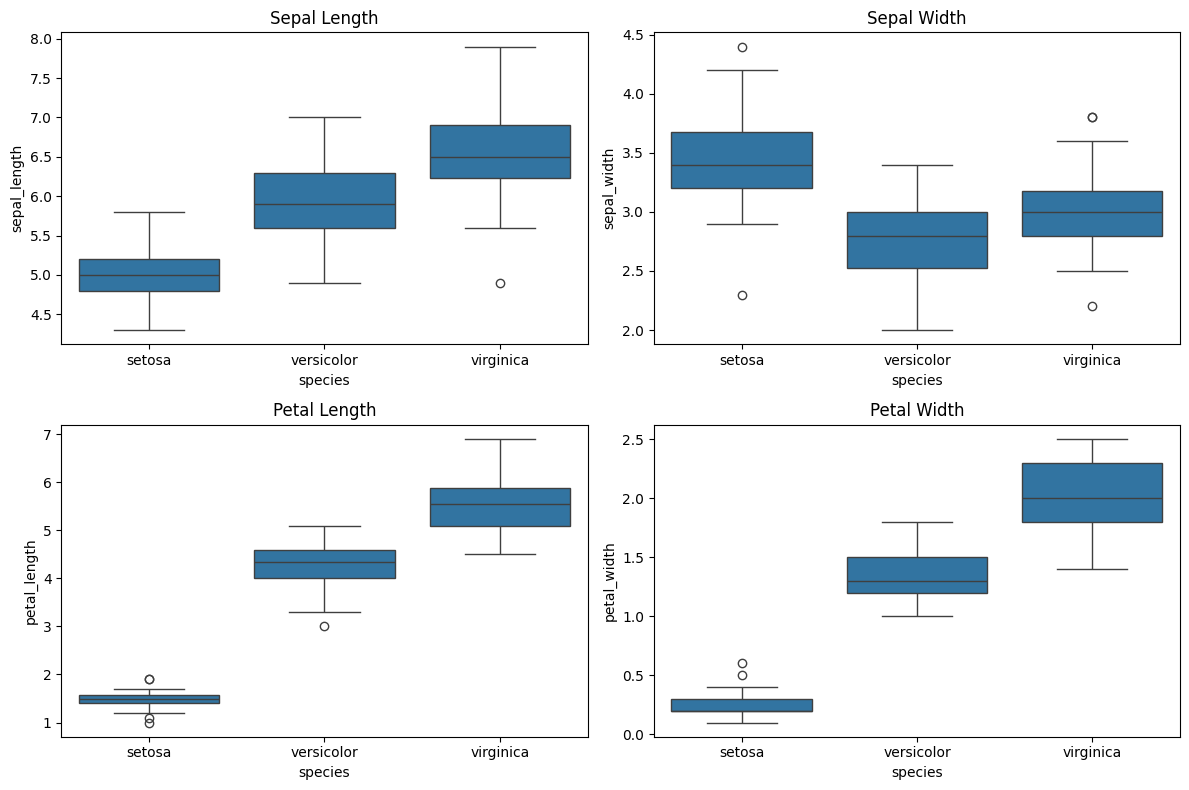

In [12]:
# Load the Iris dataset
iris = sns.load_dataset("iris")

# Create a box plot for each feature
plt.figure(figsize = (12, 8))

# Sepal Length
plt.subplot(2, 2, 1)
sns.boxplot(x = "species", y = "sepal_length", data = iris)
plt.title("Sepal Length")

# Sepal Width
plt.subplot(2, 2, 2)
sns.boxplot(x = "species", y = "sepal_width", data = iris)
plt.title("Sepal Width")

# Petal Length
plt.subplot(2, 2, 3)
sns.boxplot(x = "species", y = "petal_length", data = iris)
plt.title("Petal Length")

# Petal Width
plt.subplot(2, 2, 4)
sns.boxplot(x = "species", y = "petal_width", data = iris)
plt.title("Petal Width")

plt.tight_layout()
plt.show()

## 4.2 Missing Values

In [13]:
# Missing values
data.isna()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [14]:
# Sum of missing values
data.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Since there are no missing values, we move forward to duplicates

## 4.3 Duplicates

In [15]:
# Duplicates
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [16]:
#Sum of duplicates
data.duplicated().sum()

1

Since there are no missing values, we move forward to outliers

## 4.4 Outliers

It seems SepalWidthCm has values which divert significantly from the rest of the values.

In [17]:
# Function to detect any outliers
def detect_outliers_iqr(data, features):
    outlier_indices = {}
    
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_indices[feature] = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)].index.tolist()
        
    return outlier_indices

In [18]:
#Checking in each column for outliers
outlier_indices = detect_outliers_iqr(data, ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'])

# Print the results
for feature, indices in outlier_indices.items():
    print(f"Outliers in {feature}: {indices}")

Outliers in sepal length (cm): []
Outliers in sepal width (cm): [15, 32, 33, 60]
Outliers in petal length (cm): []
Outliers in petal width (cm): []


In [19]:
# Get the flower species for the outliers
outliers_species = data.loc[outlier_indices['sepal width (cm)'], 'target']

# Print the results
print("Flower species for outliers in sepal width (cm):")
print(outliers_species)

Flower species for outliers in sepal width (cm):
15    0
32    0
33    0
60    1
Name: target, dtype: int32


Three of the four outliers belong to the setosa flower group while only 1 belong to versicolor

In [21]:
outlier_count = len(outlier_indices['sepal width (cm)'])
total_rows = len(data['sepal width (cm)'])
percentage_outliers = (outlier_count / total_rows) * 100
print("Percentage of outliers in 'sepal width (cm)' column:", percentage_outliers)

Percentage of outliers in 'sepal width (cm)' column: 2.666666666666667


That's quite small so we can drop them

In [22]:
#Creating a new dataset without outliers
cleaned_data = data.drop(outlier_indices['sepal width (cm)'])
cleaned_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [23]:
#For the purposes of simplicity
data = cleaned_data
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [63]:
data["target"].value_counts()

target
2    50
1    49
0    47
Name: count, dtype: int64

## 4.5 Visualizing After Data Cleaning

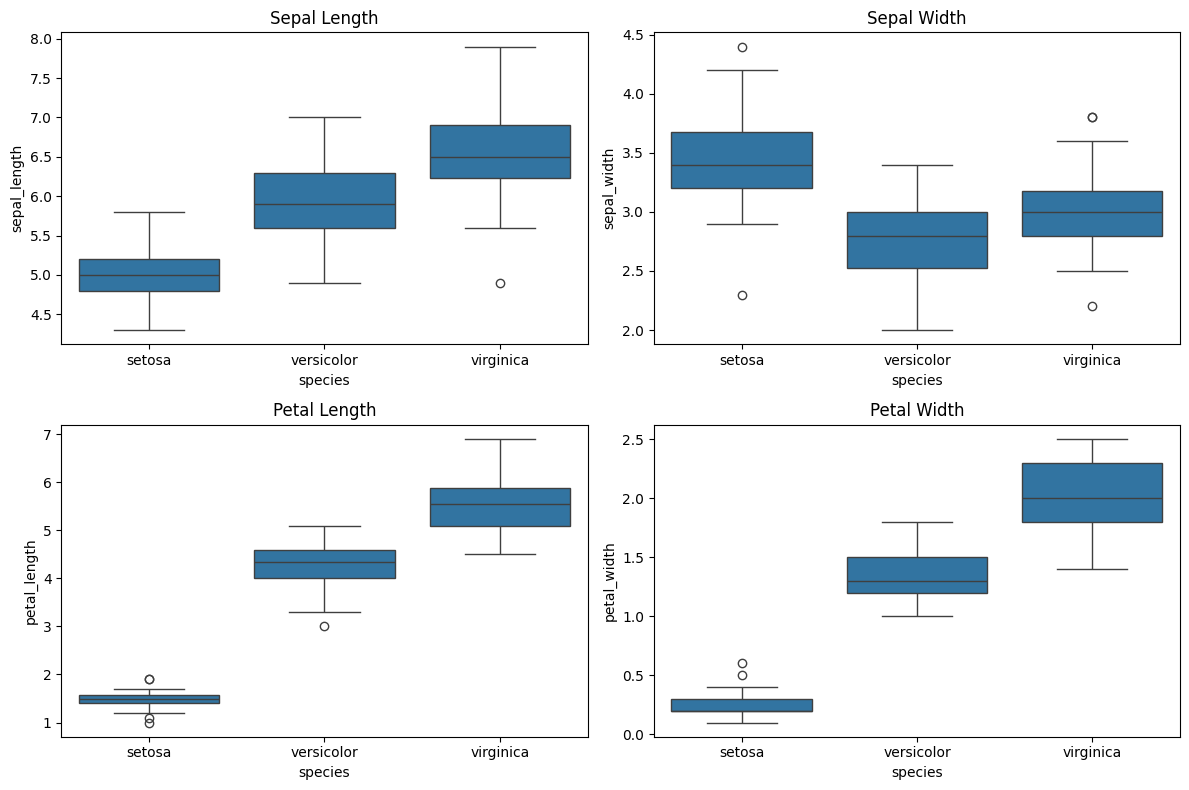

In [24]:
# Load the Iris dataset
iris = sns.load_dataset("iris")

# Create a box plot for each feature
plt.figure(figsize = (12, 8))

# Sepal Length
plt.subplot(2, 2, 1)
sns.boxplot(x = "species", y = "sepal_length", data = iris)
plt.title("Sepal Length")

# Sepal Width
plt.subplot(2, 2, 2)
sns.boxplot(x = "species", y = "sepal_width", data = iris)
plt.title("Sepal Width")

# Petal Length
plt.subplot(2, 2, 3)
sns.boxplot(x = "species", y = "petal_length", data = iris)
plt.title("Petal Length")

# Petal Width
plt.subplot(2, 2, 4)
sns.boxplot(x = "species", y = "petal_width", data = iris)
plt.title("Petal Width")

plt.tight_layout()
plt.show()

**Interpretion**

From the visuals, dropping the outliers didn't have much effects to the data

# 5. EDA

## 5.1 Univariate Analysis

sepal length (cm)

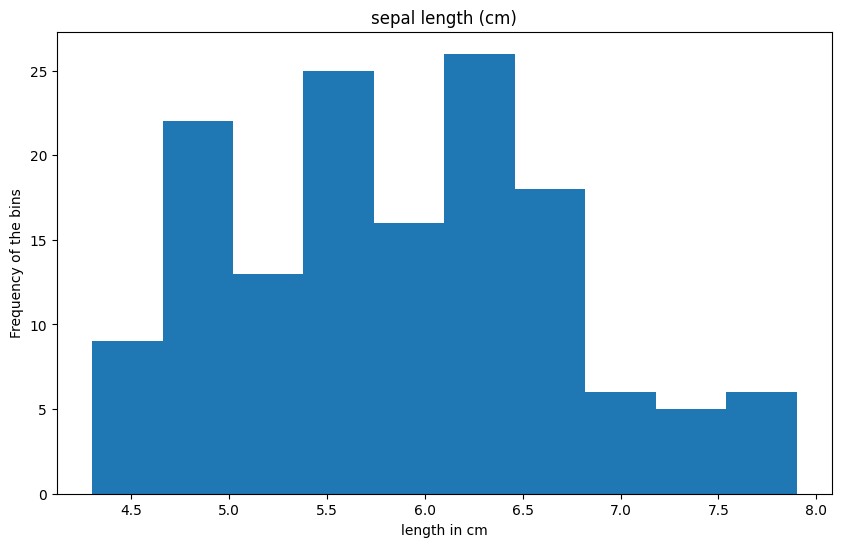

In [25]:
x = data["sepal length (cm)"]

plt.figure(figsize = (10, 6))

plt.hist(x)

plt.title("sepal length (cm)")
plt.ylabel("Frequency of the bins")
plt.xlabel("length in cm")
plt.show()

**Interpretion**

Based on the image, the mean seems to be in around 6.0 cm meaning most of the flowers sepal length range around that length

sepal width (cm)

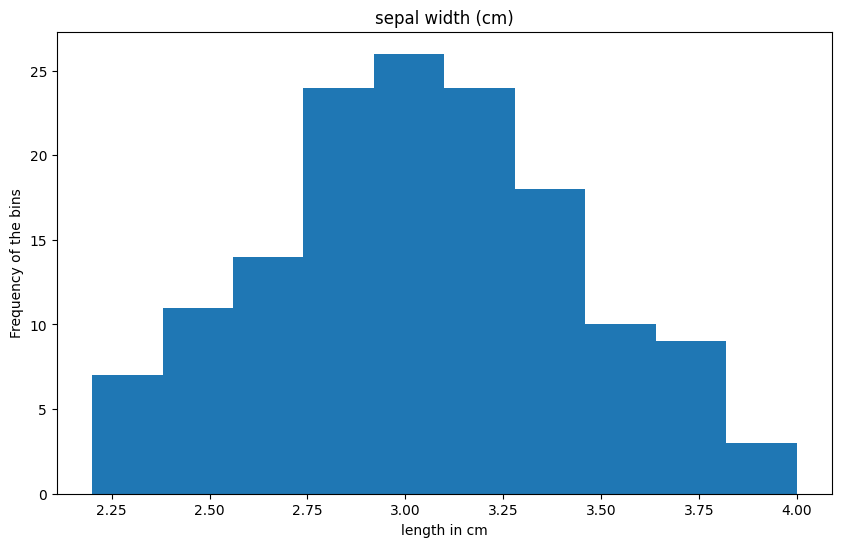

In [26]:
x = data["sepal width (cm)"]

plt.figure(figsize = (10, 6))

plt.hist(x)

plt.title("sepal width (cm)")
plt.ylabel("Frequency of the bins")
plt.xlabel("length in cm")
plt.show()

**Interpretion**

For the sepal width on the other hand, it is half the length of sepal length with most of the flowers size ranging at approximately 3.0

petal length (cm)

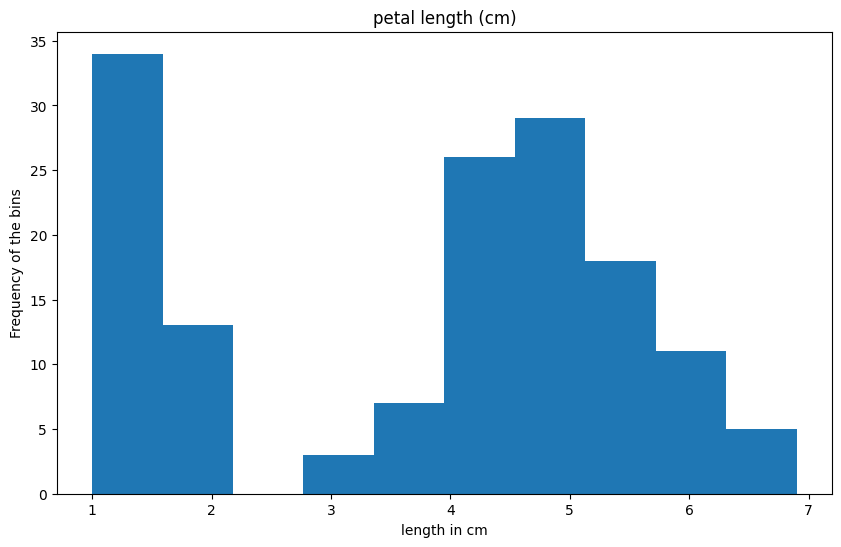

In [27]:
x = data["petal length (cm)"]

plt.figure(figsize = (10, 6))

plt.hist(x)

plt.title("petal length (cm)")
plt.ylabel("Frequency of the bins")
plt.xlabel("length in cm")
plt.show()

**Interpretion**

The length of the petals seem to be unevenly distributed with some ranging from 1 cm to 2.2 cm and from 2.7 cm to 6.8 cm. Also, there is no flower which registered a petal length of between 2.2 cm and 2.7 cm

petal width (cm)

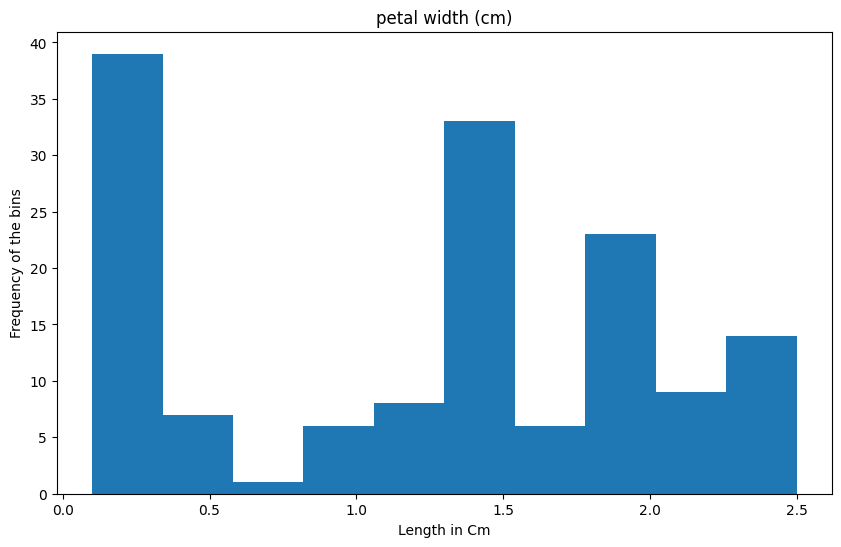

In [28]:
x = data["petal width (cm)"]

plt.figure(figsize = (10, 6))

plt.hist(x)

plt.title("petal width (cm)")
plt.ylabel("Frequency of the bins")
plt.xlabel("Length in Cm")
plt.show()

Petal width follows the same path with petal length on uneven distribution. Just like sepal width being half the mean of sepal length, petal width is half the size of petal length.

## 5.2 Bivariate Analysis

sepal length (cm) vs sepal width (cm)

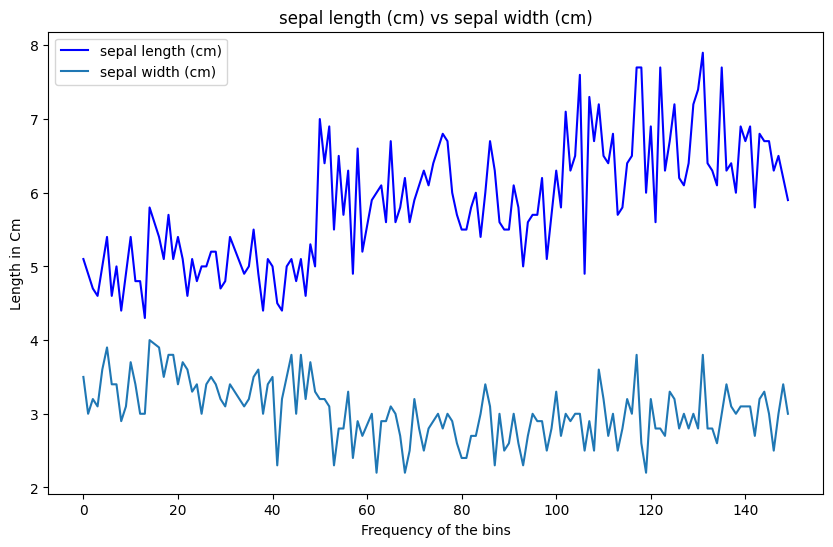

In [29]:
plt.figure(figsize = (10, 6))

plt.plot(data["sepal length (cm)"], color = "blue", label = "sepal length (cm)")
plt.plot(data["sepal width (cm)"], label = "sepal width (cm)")

plt.title("sepal length (cm) vs sepal width (cm)")
plt.ylabel("Length in Cm")
plt.xlabel("Frequency of the bins")
plt.legend()
plt.show()

**Interpretion**

As I said, the sepal length is twice the size of the sepal width. The two seem to have a fairly close distribution.

petal length (cm) vs petal width (cm)

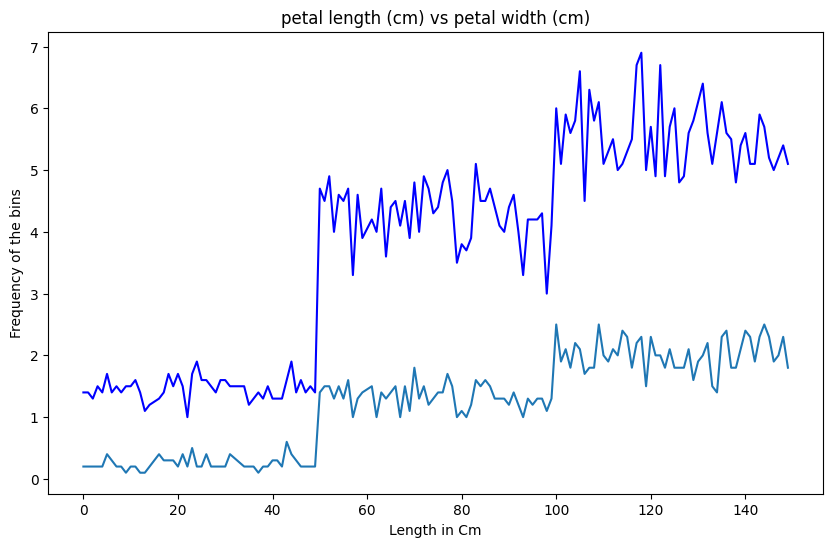

In [30]:
plt.figure(figsize = (10, 6))

plt.plot(data["petal length (cm)"], color = "blue")
plt.plot(data["petal width (cm)"])

plt.title("petal length (cm) vs petal width (cm)")
plt.ylabel("Frequency of the bins")
plt.xlabel("Length in Cm")
plt.show()

**Interpretion**

As For the petal length and petal width, business remains the same as that of sepal length and sepal width with both similarity in an evenly distribution and a similar ratio. i.e 2:1

Each Feature vs Target

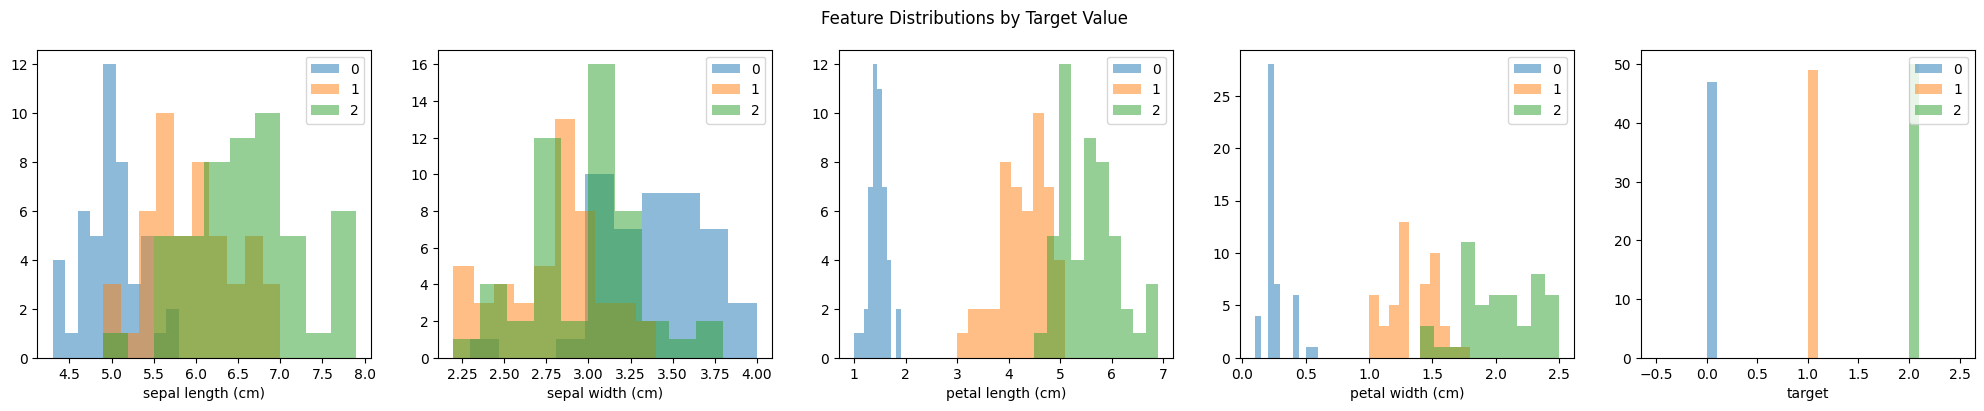

In [31]:
# Set the number of subplots based on the number of features
num_features = len(data.columns)

# Set up figure and axes
fig, axes = plt.subplots(ncols=num_features, figsize=(5*num_features, 4))

# Loop over each feature
for feature_index, (feature_name, ax) in enumerate(zip(data.columns, axes)):
    
    # Set the label for the feature
    ax.set_xlabel(feature_name)
    
    # Loop over the unique target values and plot them by color
    for target_value in data['target'].unique():
        subset_rows = data[data['target'] == target_value]
        ax.hist(
            subset_rows[feature_name],
            label=target_value,
            alpha=0.5
        )

    # Add a legend to each subplot
    ax.legend()

# Set a title for the overall plot
fig.suptitle("Feature Distributions by Target Value")
plt.show()

**Interpretion**

**N/B: This is an interpretion of where most of the length lies of different features of the each flower** </br>
**sepal length** </br>
setosa - The mean of it's sepal length is 5.0 cm </br>
versicolor - The mean of it's sepal length is 5.7 cm </br>
virginica - The mean of it's sepal length is 6.8 cm </br>

**sepal width** </br>
setosa - The mean of it's sepal width is 2.5 cm </br>
versicolor - The mean of it's sepal width is 2.8 cm </br>
virginica - The mean of it's sepal width is 3.2 cm </br>

**petal length** </br>
setosa - The mean of it's petal length is 1.5 cm </br>
versicolor - The mean of it's petal length is 4.0 cm </br>
virginica - The mean of it's petal length is 5.7 cm </br>

**petal width** </br>
setosa - The mean of it's petal width is 0.25 cm </br>
versicolor - The mean of it's petal width is 1.25 cm </br>
virginica - The mean of it's petal width is 2.0 cm </br>

**target** </br>
setosa (0) - Has 47 features </br>
versicolor (1) - Has 49 features </br>
virginica (2) - Has 50 features </br>

**The analysis above shows that width is half the size of length for each iris species which will be a very important aspect in evaulation**

## 5.3 Multivariate Analysis

Petal Width vs. Petal Length for every target

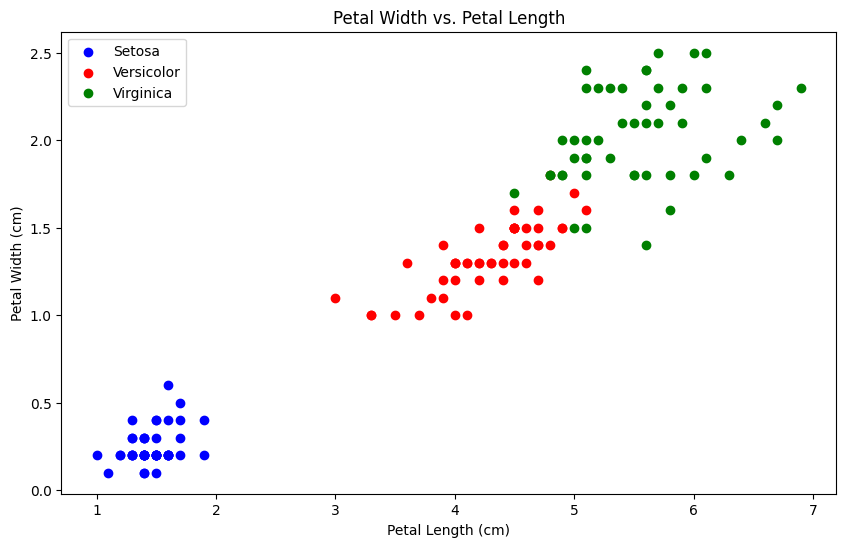

In [32]:
plt.figure(figsize=(10, 6))

# Plot data points with different colors based on species
plt.scatter(data[data["target"] == 0]["petal length (cm)"], 
            data[data["target"] == 0]["petal width (cm)"], 
            color="blue", label="Setosa")
plt.scatter(data[data["target"] == 1]["petal length (cm)"], 
            data[data["target"] == 1]["petal width (cm)"], 
            color="red", label="Versicolor")
plt.scatter(data[data["target"] == 2]["petal length (cm)"], 
            data[data["target"] == 2]["petal width (cm)"], 
            color="green", label="Virginica")

plt.title("Petal Width vs. Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()

plt.show()

**Interpretion**

setosa has the smallest petal length and petal width </br>
versicolor has intermediate petal length and petal width as compared to Setosa and virginica </br>
virginica has the largest petal length and petal width

Sepal Width vs. Sepal Length for every target

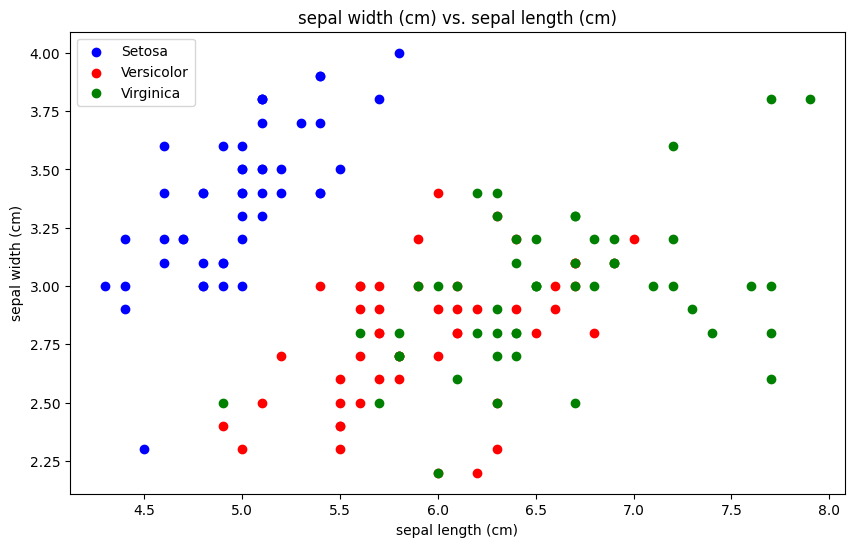

In [33]:
plt.figure(figsize=(10, 6))

# Plot data points with different colors based on species
plt.scatter(data[data["target"] == 0]["sepal length (cm)"], 
            data[data["target"] == 0]["sepal width (cm)"], 
            color="blue", label="Setosa")
plt.scatter(data[data["target"] == 1]["sepal length (cm)"], 
            data[data["target"] == 1]["sepal width (cm)"], 
            color="red", label="Versicolor")
plt.scatter(data[data["target"] == 2]["sepal length (cm)"], 
            data[data["target"] == 2]["sepal width (cm)"], 
            color="green", label="Virginica")

plt.title("sepal width (cm) vs. sepal length (cm)")
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.legend()

plt.show()

**Interpretion**

Just like in petals:
setosa has the smallest sepal length and sepal width </br>
versicolor has intermediate sepal length and sepal width as compared to Setosa and virginica </br>
virginica has the largest sepal length and sepal width

# 6. Data Preprocessing

## 6.1 Performing Train Test Split

In [34]:
# Separate X and y
X = data.drop(columns = "target")
y = data["target"]

# Perform train-test split with random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## 6.2 Scaling

In [35]:
# Instantiate a scaler
scaler = StandardScaler()

# Fit the scaler on X_train
scaler.fit(X_train)

# Transform X_train and X_test. Go ahead and reuse the variable names 
#"X_train" and "X_test" since we won't need the un-scaled data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Now the values should be scaled
pd.DataFrame(X_train, columns = data.columns[:-1])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.331669,-0.056929,0.113957,0.066337
1,0.492642,-1.297971,0.584908,0.344444
2,0.728159,-0.553346,0.408301,0.344444
3,1.199194,0.191280,0.879252,1.178765
4,0.139366,-0.056929,0.526039,0.761605
...,...,...,...,...
104,0.845918,-0.056929,0.290564,0.205391
105,0.728159,0.439488,0.702645,1.039712
106,-0.096152,2.425157,-1.593239,-1.463251
107,-0.213910,-0.305137,0.172826,0.066337


## 6.3 PCA

In [36]:
# Instantiate the PCA transformer with n_components=2
pca = PCA(n_components=2)

# Fit the transformer on X_train
pca.fit(X_train)

# Transform X_train and X_test. This time, create new variables for the transformed data
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [37]:
train_combined_pca = pd.DataFrame(X_train_pca, columns=["PC 1", "PC 2"])
train_combined_pca["target"] = y_train.values
train_combined_pca

,PC 1,PC 2,target
0,0.061405,-0.159133,1
1,-1.063715,-1.061999,1
2,-0.937641,-0.280080,1
3,-1.795794,0.603098,2
4,-0.830951,0.014884,2
...,...,...,...
104,-0.753083,0.223272,1
105,-1.310497,0.682799,2
106,2.308747,2.223068,0
107,-0.085796,-0.356635,1


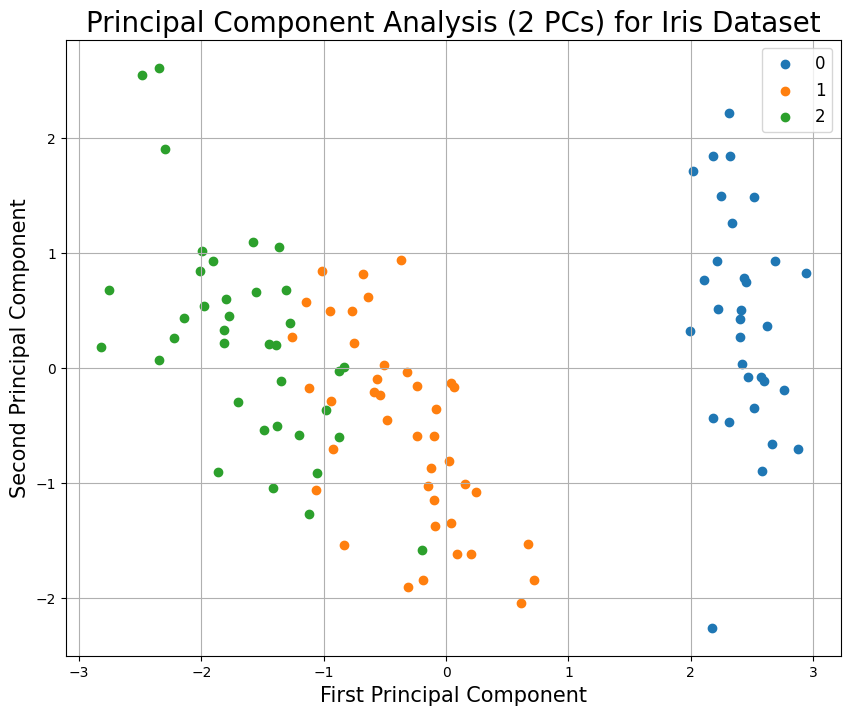

In [38]:
# Set up figure and axes
plt.figure(figsize = (10, 8))
plt.grid()

# Scatter plot of the transformed PCA data
for species in data["target"].unique():
    plt.scatter(train_combined_pca[train_combined_pca["target"] == species]["PC 1"], 
                train_combined_pca[train_combined_pca["target"] == species]["PC 2"], 
                label=species)

# Customize labels
plt.xlabel("First Principal Component", fontsize = 15)
plt.ylabel("Second Principal Component", fontsize = 15)
plt.title("Principal Component Analysis (2 PCs) for Iris Dataset", fontsize = 20)
plt.legend(fontsize = "large")

plt.show()

The three classes in the dataset are fairly well separable, even though the data has been projected into two dimensions (down from 4 dimensions). As such, this compressed representation of the data is probably sufficient for the classification task at hand.

## 6.4 Correlation

One last thing befoe we get into modelling, It is always good to know how the features are dependent on each other to know which Data Model to use.

In [39]:
x = train_combined_pca.drop(columns = "target")
correlation_matrix = x.corr()
print(correlation_matrix)

              PC 1          PC 2
PC 1  1.000000e+00 -7.379491e-17
PC 2 -7.379491e-17  1.000000e+00


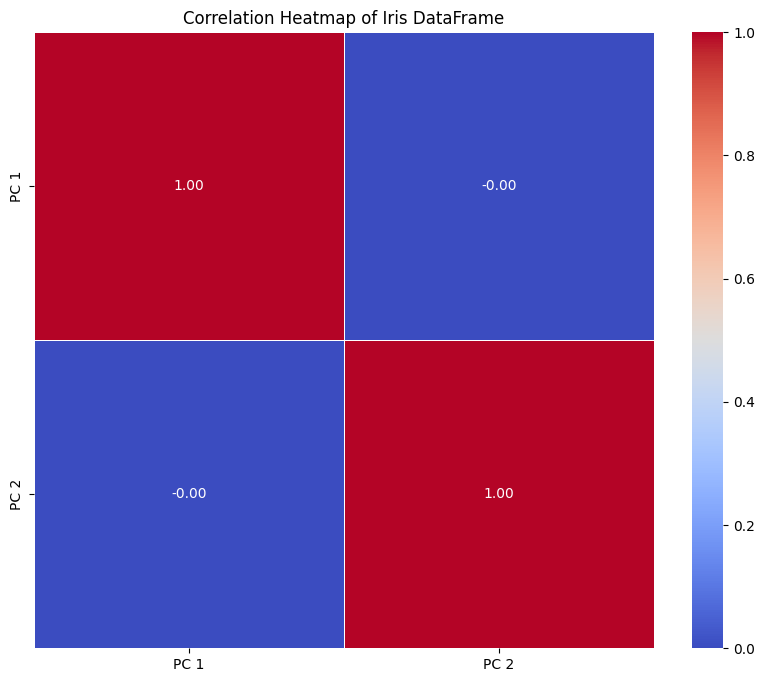

In [40]:
# Calculate the correlation matrix
correlation_matrix = x.corr()

# Create a heatmap
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths = 0.5)
plt.title("Correlation Heatmap of Iris DataFrame")
plt.show()

**Interpretion**

The correlation between PC1 and PC2 is approximately zero. This implies that there is no linear relationship between PC1 and PC2 in the dataset.

# 7. Data Modelling

## 7.1 Logistic Regression 

Used it as my baseline model

In [41]:
# Initiliazing the model
pca_model = LogisticRegression(random_state=42)
pca_model

LogisticRegression(random_state=42)

In [42]:
# Fit the model on the training data
pca_model.fit(X_train_pca, y_train)

LogisticRegression(random_state=42)

Evaluation

In [43]:
# Predict the target values for the test data
y_pred = pca_model.predict(X_test_pca)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.95


## 7.2 SVM

In [44]:
# Initialize SVM model
svm_model = SVC(kernel = "linear", C = 1.0, random_state = 42)

# Train the SVM model on the scaled training data
svm_model.fit(X_train_pca, y_train)

# Make predictions on the scaled test set
svm_predictions = svm_model.predict(X_test_pca)

Evaluation

In [45]:
# Evaluate the performance of the SVM model
accuracy = accuracy_score(y_test, svm_predictions)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9459


## 7.3 Decision Trees

In [46]:
# creating a classifier and fitting it
clf = DecisionTreeClassifier(random_state = 42)
clf.fit(X_train_pca, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
# Making predictions on both the train and test data
y_train_predict = clf.predict(X_train_pca)
y_test_predict = clf.predict(X_train_pca)

In [48]:
# model evaluation
accuracy = accuracy_score(y_train_predict, y_test_predict)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 1.0000


Seems there is overfitting, we need to prune the tree

In [65]:
# Create a DecisionTreeClassifier with cost complexity pruning
clf_pruned = DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)
clf_pruned.fit(X_train_pca, y_train)

# Making predictions on the test data using the pruned classifier
y_test_predict = clf_pruned.predict(X_test_pca)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_test_predict)
print("Accuracy:", accuracy)

Accuracy: 0.9459459459459459


## 7.4 Random Forest

In [50]:
#Create a Random Forest Classifier with 100 trees
clf = RandomForestClassifier(n_estimators = 100)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

In [51]:
# Model Accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9459459459459459


## 7.5 KNN

In [52]:
knn = KNeighborsClassifier(n_neighbors = 5)

# Fit the classifier to the training data
knn.fit(X_train_pca, y_train)

# Make predictions on the test data
y_pred = knn.predict(X_test_pca)

In [53]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy", accuracy)

Accuracy 0.9459459459459459


## 7.6 Neural Networks

In [54]:
# One-hot encode the target data
target_encoded = to_categorical(y_train)

# defining the model
model = models.Sequential()

# adding input layer
model.add(layers.Dense(units=100, activation = "relu", input_shape = (2,))) 

# adding hidden layers
model.add(layers.Dense(units = 64, activation = "relu"))
model.add(layers.Dense(units = 32, activation = "relu"))

# adding output layer with appropriate units and activation function
model.add(layers.Dense(units=3, activation = "softmax"))  

# compiling the model
model.compile(optimizer = optimizers.Adam(learning_rate = 0.001), loss = "categorical_crossentropy", metrics = ["accuracy"])

# fitting the model
history = model.fit(X_train_pca, target_encoded, epochs=20, batch_size = 32)

# displaying training loss
train_loss = history.history["loss"]
epochs = range(1, len(train_loss) + 1)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2006 - loss: 1.1223
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3234 - loss: 1.0118 
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7227 - loss: 0.9135 
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7541 - loss: 0.8617 
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7703 - loss: 0.7886 
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7922 - loss: 0.7493 
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7870 - loss: 0.7209 
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8094 - loss: 0.6977 
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8303 - loss: 0.6462 
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8172 - loss: 0.6225 
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8074 - loss: 0.6095 
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8011 - loss: 0.5619 
Ep

In [55]:
# One-hot encode the target data
target_encoded_test = to_categorical(y_test)

# Evaluate the model on the test data
accuracy = model.evaluate(X_test_pca, target_encoded_test)

print("accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9147 - loss: 0.2689 
accuracy: [0.2704325318336487, 0.9189189076423645]


# 8. Evaluation

Ease of Interpretation: Accuracy is an intuitive and easily interpretable metric. It represents the percentage of correct predictions among all predictions made by the model. Users, including hotel staff, can readily understand and trust this metric.

Clear Benchmark: Accuracy provides a clear benchmark for evaluating model performance. It answers the basic question: "How often is the model correct?" This simplicity can be advantageous for communication and decision-making.

Balanced Classes: If the classes of interest (e.g., setosa, versicolor, virginica) are roughly balanced, accuracy can be an effective measure. It doesn't favor one class over another and provides a sense of overall correctness.

I tested and from that we choose the best 3 performing models which are : </br>

Logistic regression = 95% </br>
Random Forest = 94% </br>
KNN = 94%

Let's do some tests to see how our models perform

First thing first: we input some sample data

In [56]:
# Define a dictionary mapping numeric labels to class names
class_names = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}

## 8.1 Logistic Regression Model Test

In [57]:
# # Creating the model pickle files
# pca_model = LogisticRegression()
# # Fit the model on the training data
# pca_model.fit(X_train_pca, y_train)
# pca_model_file_path = "logistic_regression.pkl"

# with open(pca_model_file_path, "wb") as pca_model_file:
#      pickle.dump(pca_model, pca_model_file)

In [58]:
# # Read input as a string
# sample_input = input("Enter sample data separated by commas (e.g., 5.1,3.5,1.4,0.2): ")

# # Split the input string by commas and convert to float
# sample_values = [float(value.strip()) for value in sample_input.split(",")]

# # Transform the sample data using the PCA transformation trained on the training data
# sample_transformed = pca.transform([sample_values])

# # Make predictions on the transformed new data
# logistic_regression_predictions = pca_model.predict(sample_transformed)

# # Map the numeric labels to class names
# predicted_class_name = class_names[logistic_regression_predictions[0]]

# # Print predictions
# print("Logistic Regression Prediction for this sample:", predicted_class_name)

## 8.2 Random Forest Model Test

In [59]:
# random_forest_model = RandomForestClassifier()
# #Train the model using the training sets y_pred=clf.predict(X_test)
# random_forest_model.fit(X_train_pca, y_train)
# random_forest_model_file_path = "random_forest.pkl"

# with open(random_forest_model_file_path, "wb") as random_forest_model_file:
#      pickle.dump(random_forest_model, random_forest_model_file)

In [60]:
# # Read input as a string
# sample_input = input("Enter sample data separated by commas (e.g., 5.1,3.5,1.4,0.2): ")

# # Split the input string by commas and convert to float
# sample_values = [float(value.strip()) for value in sample_input.split(",")]

# # Transform the sample data using the PCA transformation trained on the training data
# sample_transformed = pca.transform([sample_values])

# # Make predictions on the transformed new data
# random_forest_predictions = random_forest_model.predict(sample_transformed)

# # Map the numeric labels to class names
# predicted_class_name = class_names[random_forest_predictions[0]]

# # Print predictions
# print("Random Forest Prediction for this sample:", predicted_class_name)

## 8.3 KNN Model Test

In [61]:
# KNN_model = KNeighborsClassifier()
# KNN_model_file_path = "KNN.pkl"
# KNN_model.fit(X_train_pca, y_train)

# with open(KNN_model_file_path, "wb") as KNN_model_file:
#      pickle.dump(KNN_model, KNN_model_file)

In [62]:
# # Read input as a string
# sample_input = input("Enter sample data separated by commas (e.g., 5.1,3.5,1.4,0.2): ")

# # Split the input string by commas and convert to float
# sample_values = [float(value.strip()) for value in sample_input.split(",")]

# # Transform the sample data using the PCA transformation trained on the training data
# sample_transformed = pca.transform([sample_values])

# # Make predictions on the transformed new data
# KNN_predictions = KNN_model.predict(sample_transformed)

# # Map the numeric labels to class names
# predicted_class_name = class_names[KNN_predictions[0]]

# # Print predictions
# print("KNN Prediction for this sample:", predicted_class_name)

# 9. Conclusions And Recommendations

1. It provides a good example for exploring various machine learning techniques, particularly classification algorithms.

2. Petal length and sepal length are twice the size of petal width and sepal width.

3. Feature importance analysis: It can provide insights into which features contribute the most to the classification task. This information can be valuable for understanding the underlying characteristics of the data and potentially simplifying the model by focusing on the most relevant features.

4. Outlier detection and removal, as demonstrated in the analysis, can improve model performance by reducing the impact of noisy data points. However, it's essential to exercise caution and consider the domain knowledge when deciding how to handle outliers like I did. But mostly justify.

5. It's essential to monitor the model's performance over time and periodically retrain it with new data to ensure its effectiveness.

# 10. Challenges

1. Dataset was too small - Used input method to enable users to input their own sample data

2. Does not demonstrate real world applications due to it's small nature, rather, I used it to simply demonstrate Machine learning concepts